# Week 5 — Value Functions and Policy Evaluation

Based on Sutton & Barto — *Reinforcement Learning: An Introduction*, Chapter 3 (value functions) and Chapter 4 start (policy evaluation).

## Context

Week 4 introduced Markov Decision Processes using a Gridworld environment and compared three fixed policies by their average return, episode length, and success rate.

Week 5 builds on the same Gridworld and asks a different question:

> Given that we are following a fixed policy, **how good is each state?**

This is the question that **value functions** answer.

The main tools this week are:
- The **state-value function** v<sub>pi</sub>(s)
- The **action-value function** q<sub>pi</sub>(s, a)
- The **Bellman expectation equation**
- **Iterative policy evaluation**

**This week does not improve the policy.** It only evaluates a fixed policy.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

from src.gridworld.environment import GridworldMDP
from src.gridworld.policies import RandomPolicy, GoalDirectedPolicy, BadPolicy
from src.gridworld.policy_evaluation import (
    iterative_policy_evaluation,
    values_to_grid,
    manual_bellman_update_details,
)
from src.utils.plotting import (
    plot_value_function_grid,
    plot_value_convergence,
    plot_policy_value_comparison,
)

print("Imports OK")

Imports OK


## State-Value Function

The **state-value function** v<sub>pi</sub>(s) is the expected return when starting in state s and following policy pi thereafter.

v<sub>pi</sub>(s) = E<sub>pi</sub>[ G<sub>t</sub> | S<sub>t</sub> = s ]

Where G<sub>t</sub> is the discounted return:

G<sub>t</sub> = R<sub>t+1</sub> + gamma R<sub>t+2</sub> + gamma<sup>2</sup> R<sub>t+3</sub> + ...

Key points:
- The value depends entirely on the policy. A good policy makes states more valuable.
- Terminal states have value 0 by convention (no future return after reaching the goal).
- States closer to the goal under a good policy generally have higher values.

## Action-Value Function

The **action-value function** q<sub>pi</sub>(s, a) is the expected return when starting in state s, taking action a, and then following policy pi.

q<sub>pi</sub>(s, a) = E<sub>pi</sub>[ G<sub>t</sub> | S<sub>t</sub> = s, A<sub>t</sub> = a ]

The relationship between the two functions:

v<sub>pi</sub>(s) = sum<sub>a</sub> pi(a | s) q<sub>pi</sub>(s, a)

The state value is the policy-weighted average of the action values.

Note: q<sub>pi</sub> becomes central in SARSA and Q-learning in later weeks.

## Bellman Expectation Equation

The return satisfies a recursive relationship:

G<sub>t</sub> = R<sub>t+1</sub> + gamma G<sub>t+1</sub>

Substituting into the definition of v<sub>pi</sub>(s) gives the **Bellman expectation equation**:

v<sub>pi</sub>(s) = sum<sub>a</sub> pi(a | s) sum<sub>s', r</sub> p(s', r | s, a) [ r + gamma v<sub>pi</sub>(s') ]

Since the Week 4 Gridworld is **deterministic**, `p(s', r | s, a) = 1` for a unique (s', r). So the equation simplifies to:

v<sub>pi</sub>(s) = sum<sub>a</sub> pi(a | s) [ r(s, a) + gamma v<sub>pi</sub>(s') ]

where s' is the unique next state from taking action a in state s.

The key insight: the value of a state is defined in terms of the values of its successors. This allows iterative solution.

## Bellman Backup

A **Bellman backup** is one application of the Bellman expectation equation to update a single state value:

V<sub>new</sub>(s) = sum<sub>a</sub> pi(a | s) [ r(s, a) + gamma V(s') ]

- It replaces the old estimate of V(s) with an improved estimate.
- Repeating this for all states until the updates are small is **iterative policy evaluation**.
- The convergence criterion is: delta = max<sub>s</sub> | V<sub>new</sub>(s) - V(s) | < theta

## Setup — Environment and Policies

In [2]:
# Create the Week 4 Gridworld environment
env = GridworldMDP()

print(f"Grid size:    {env.grid_size}")
print(f"Start state:  {env.start_state}")
print(f"Goal state:   {env.goal_state}")
print(f"Obstacles:    {sorted(env.obstacles)}")
print(f"Valid states: {len(env.get_all_states())} (out of {env.grid_size[0] * env.grid_size[1]} total)")
print(f"\nRewards:")
print(f"  Normal step:  {env.step_reward}")
print(f"  Invalid move: {env.invalid_move_reward}")
print(f"  Goal:         {env.goal_reward}")
print()
print(env.render())

Grid size:    (5, 5)
Start state:  (0, 0)
Goal state:   (4, 4)
Obstacles:    [(1, 1), (1, 3), (2, 3), (3, 0), (4, 2)]
Valid states: 20 (out of 25 total)

Rewards:
  Normal step:  -1.0
  Invalid move: -5.0
  Goal:         10.0

A . . . .
. X . X .
. . . X .
X . . . .
. . X . G


In [3]:
# Create the three fixed policies from Week 4
random_policy = RandomPolicy(seed=42)

goal_policy = GoalDirectedPolicy(
    goal_state=env.goal_state,
    grid_size=env.grid_size,
    obstacles=env.obstacles,
    exploration_prob=0.1,
    seed=42,
)

bad_policy = BadPolicy(seed=42)

# Show action probability distributions at the start state
state = env.start_state
print(f"Action probabilities at start state {state}:")
print()
print(f"{'Action':<8}  {'Random':>8}  {'GoalDir':>8}  {'Bad':>8}")
print("-" * 40)
for action in env.get_valid_actions():
    rp = random_policy.get_action_probabilities(state)[action]
    gp = goal_policy.get_action_probabilities(state)[action]
    bp = bad_policy.get_action_probabilities(state)[action]
    print(f"{action:<8}  {rp:>8.3f}  {gp:>8.3f}  {bp:>8.3f}")

Action probabilities at start state (0, 0):

Action      Random   GoalDir       Bad
----------------------------------------
up           0.250     0.025     0.425
down         0.250     0.475     0.075
left         0.250     0.025     0.425
right        0.250     0.475     0.075


## Iterative Policy Evaluation

**Algorithm:**
1. Initialise V(s) = 0 for all valid non-obstacle states.
2. Sweep through all states:
   - For each non-terminal state s: apply the Bellman backup.
   - Compute delta = max<sub>s</sub> | V<sub>new</sub>(s) - V(s) |.
   - Replace V with V<sub>new</sub>.
3. Repeat until delta < theta.

Parameters used below:
- `gamma = 0.9`
- `theta = 1e-4`
- `max_iterations = 1000`

In [4]:
GAMMA = 0.9
THETA = 1e-4
MAX_ITER = 1000

# --- Random Policy ---
random_values, random_history = iterative_policy_evaluation(
    env, random_policy, gamma=GAMMA, theta=THETA, max_iterations=MAX_ITER
)

print("Random Policy evaluation:")
print(f"  Sweeps to converge:  {len(random_history)}")
print(f"  Final delta:         {random_history[-1]:.2e}")
print(f"  Min non-terminal V:  {min(v for s, v in random_values.items() if not env.is_terminal(s)):.4f}")
print(f"  Max non-terminal V:  {max(v for s, v in random_values.items() if not env.is_terminal(s)):.4f}")
print(f"  Goal state V:        {random_values[env.goal_state]:.4f}")

Random Policy evaluation:
  Sweeps to converge:  92
  Final delta:         9.90e-05
  Min non-terminal V:  -31.5086
  Max non-terminal V:  -5.3459
  Goal state V:        0.0000


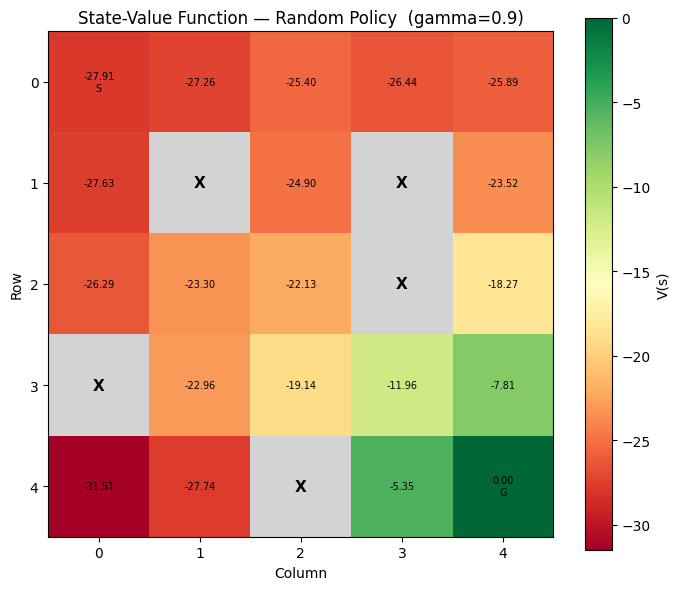

In [5]:
random_grid = values_to_grid(random_values, env)
plot_value_function_grid(
    random_grid,
    env,
    title="State-Value Function - Random Policy (gamma=0.9)",
)

In [6]:
# --- Goal-Directed Policy ---
goal_values, goal_history = iterative_policy_evaluation(
    env, goal_policy, gamma=GAMMA, theta=THETA, max_iterations=MAX_ITER
)

print("Goal-Directed Policy evaluation:")
print(f"  Sweeps to converge:  {len(goal_history)}")
print(f"  Final delta:         {goal_history[-1]:.2e}")
print(f"  Min non-terminal V:  {min(v for s, v in goal_values.items() if not env.is_terminal(s)):.4f}")
print(f"  Max non-terminal V:  {max(v for s, v in goal_values.items() if not env.is_terminal(s)):.4f}")
print(f"  Goal state V:        {goal_values[env.goal_state]:.4f}")

Goal-Directed Policy evaluation:
  Sweeps to converge:  37
  Final delta:         6.90e-05
  Min non-terminal V:  -4.3881
  Max non-terminal V:  9.6209
  Goal state V:        0.0000


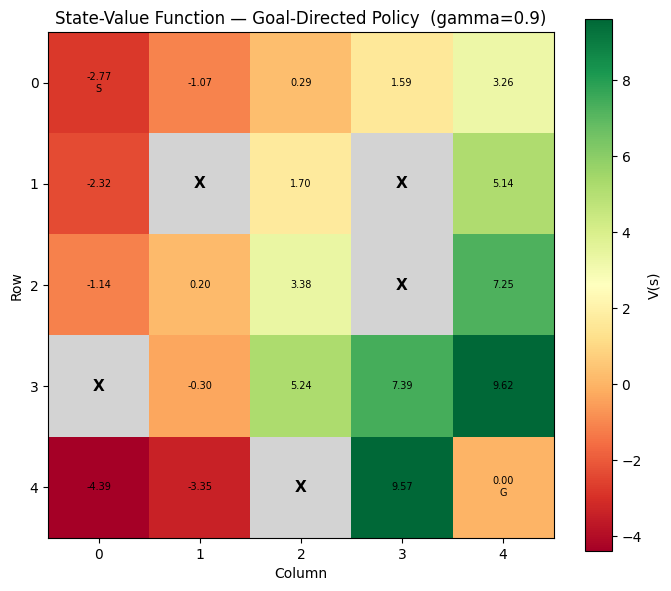

In [7]:
goal_grid = values_to_grid(goal_values, env)
plot_value_function_grid(
    goal_grid,
    env,
    title="State-Value Function - Goal-Directed Policy (gamma=0.9)",
)

In [8]:
# --- Bad Policy ---
bad_values, bad_history = iterative_policy_evaluation(
    env, bad_policy, gamma=GAMMA, theta=THETA, max_iterations=MAX_ITER
)

print("Bad Policy evaluation:")
print(f"  Sweeps to converge:  {len(bad_history)}")
print(f"  Final delta:         {bad_history[-1]:.2e}")
print(f"  Min non-terminal V:  {min(v for s, v in bad_values.items() if not env.is_terminal(s)):.4f}")
print(f"  Max non-terminal V:  {max(v for s, v in bad_values.items() if not env.is_terminal(s)):.4f}")

Bad Policy evaluation:
  Sweeps to converge:  102
  Final delta:         9.48e-05
  Min non-terminal V:  -42.0411
  Max non-terminal V:  -23.3248


## Convergence Plot

The convergence history shows how the maximum value change (delta) decreases across sweeps. When delta drops below theta (1e-4), evaluation is considered complete.

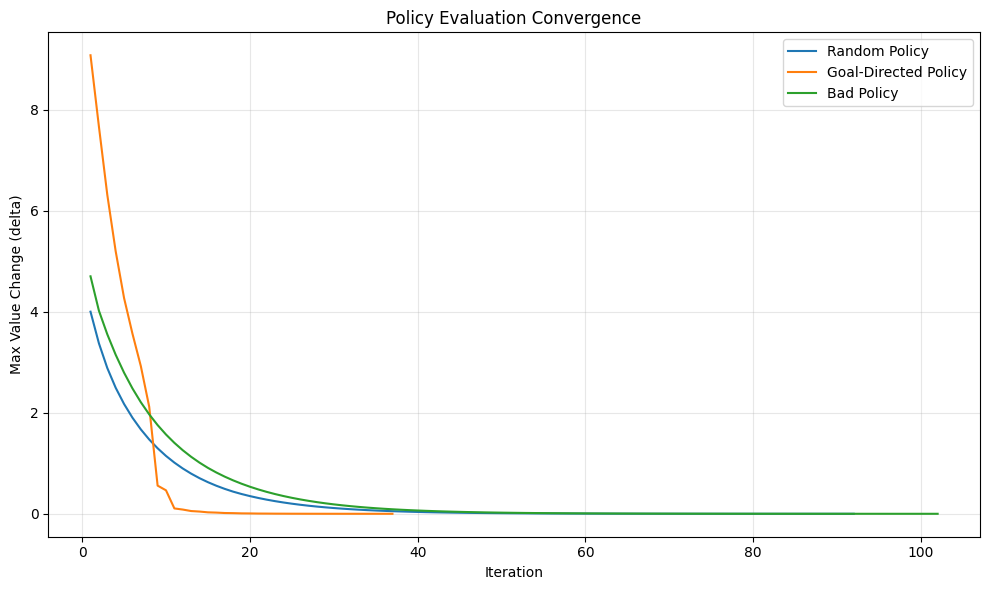

In [9]:
convergence_histories = {
    "Random Policy": random_history,
    "Goal-Directed Policy": goal_history,
    "Bad Policy": bad_history,
}

plot_value_convergence(convergence_histories)

## Manual Bellman Update

To build intuition, we trace through a single Bellman backup for state **(0, 0)** - the start state - under the **Random Policy**.

At state (0, 0):
- Actions `up` and `left` hit the grid boundary — the agent stays in (0, 0) with reward -5.
- Actions `down` and `right` are valid moves with reward -1.

Each action's contribution = pi(a | s) · (r + gamma · V(s')).

In [10]:
example_state = (0, 0)

details = manual_bellman_update_details(
    env, random_policy, random_values, example_state, gamma=GAMMA
)

print(f"Bellman backup for state {details['state']}  (Random Policy, gamma={GAMMA}):")
print()
print(f"{'Action':<8} {'pi(a|s)':>8} {'s\'':>10} {'r':>7} {'V(s\')':>10} {'contrib':>10}")
print("-" * 58)
for d in details["action_details"]:
    print(
        f"{d['action']:<8} {d['probability']:>8.4f} "
        f"{str(d['next_state']):>10} {d['reward']:>7.1f} "
        f"{d['next_state_value']:>10.4f} {d['contribution']:>10.4f}"
    )
print("-" * 58)
print(f"{'Updated V(s)':>46} {details['updated_value']:>10.4f}")
print(f"{'Current V(s)':>46} {random_values[example_state]:>10.4f}")
print()
print("(At convergence, updated V(s) ~= current V(s))")

Bellman backup for state (0, 0)  (Random Policy, gamma=0.9):

Action    pi(a|s)         s'       r      V(s')    contrib
----------------------------------------------------------
up         0.2500     (0, 0)    -5.0   -27.9087    -7.5295
down       0.2500     (1, 0)    -1.0   -27.6261    -6.4659
left       0.2500     (0, 0)    -5.0   -27.9087    -7.5295
right      0.2500     (0, 1)    -1.0   -27.2623    -6.3840
----------------------------------------------------------
                                  Updated V(s)   -27.9088
                                  Current V(s)   -27.9087

(At convergence, updated V(s) ~= current V(s))


The table shows what happens in one Bellman backup:

- Each action contributes pi(a | s) · (r + gamma · V(s')) to the new state value.
- Invalid actions (up, left) return to (0, 0) with reward -5, so their next-state value is V(0,0) itself.
- Valid actions (down, right) transition to neighbours with reward -1.
- The updated value is the sum of all four contributions.

At convergence (shown above), the updated value matches the current value - this is what it means for V to satisfy the Bellman equation.

## Policy Value Comparison

We compute the average state value (excluding the terminal goal state) for each policy and compare them visually.

Average state value (non-terminal states):
  Random Policy         : -22.3890
  Goal-Directed Policy  : +2.0684
  Bad Policy            : -33.2459


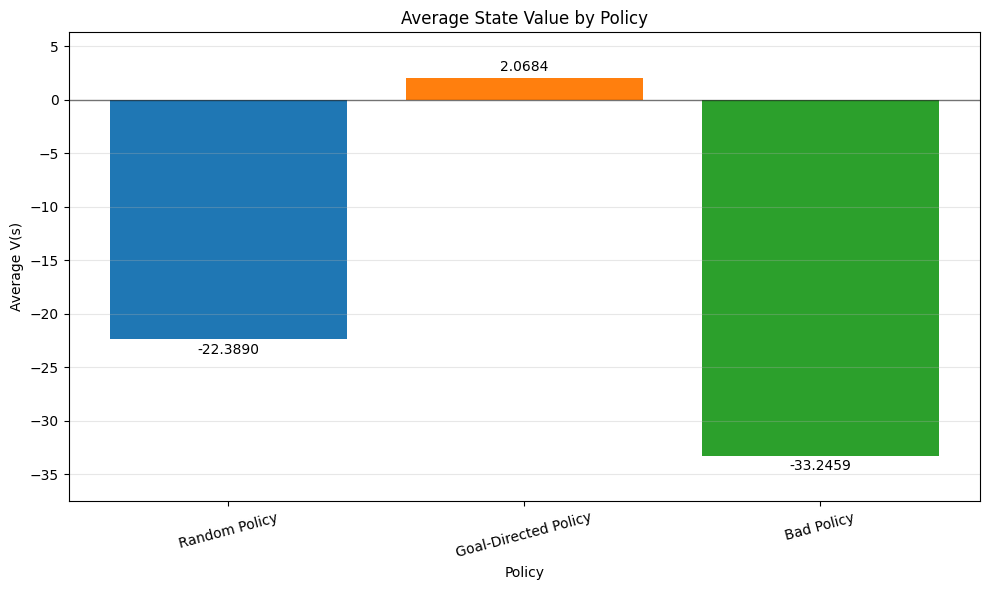

In [11]:
def avg_nonterminal_value(values, env):
    """Average V(s) over non-terminal valid states."""
    nonterminal = [v for s, v in values.items() if not env.is_terminal(s)]
    return float(np.mean(nonterminal))

avg_values = {
    "Random Policy":       avg_nonterminal_value(random_values, env),
    "Goal-Directed Policy": avg_nonterminal_value(goal_values, env),
    "Bad Policy":           avg_nonterminal_value(bad_values, env),
}

print("Average state value (non-terminal states):")
for name, val in avg_values.items():
    print(f"  {name:<22}: {val:+.4f}")

plot_policy_value_comparison(avg_values)

## Save Plots to results/week_05/

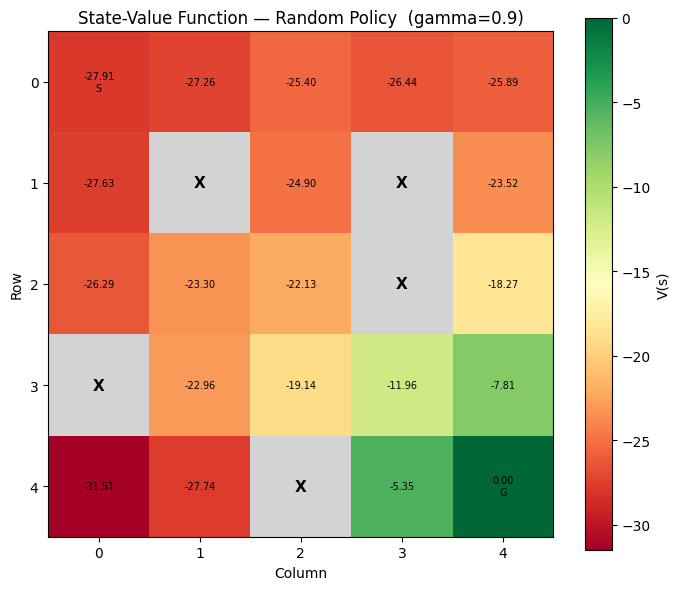

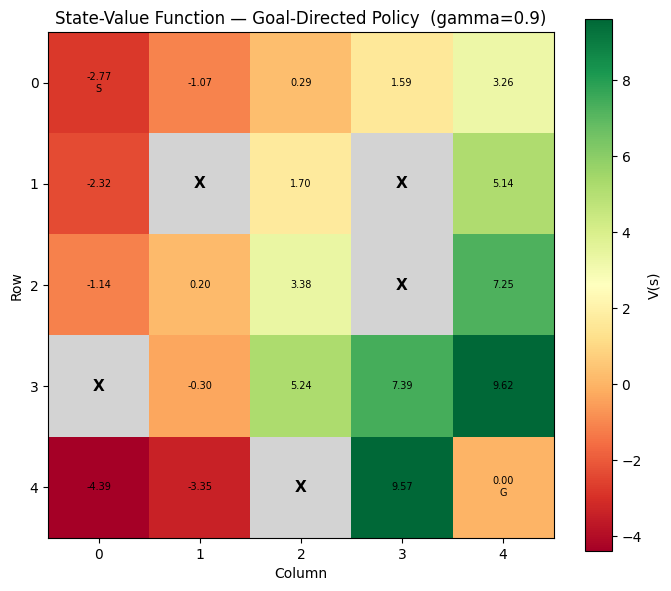

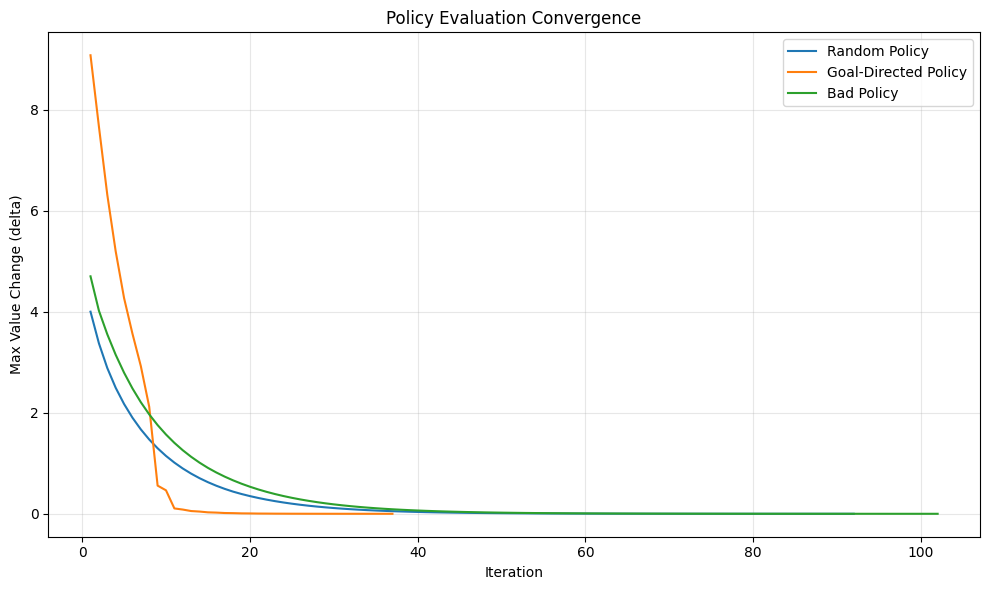

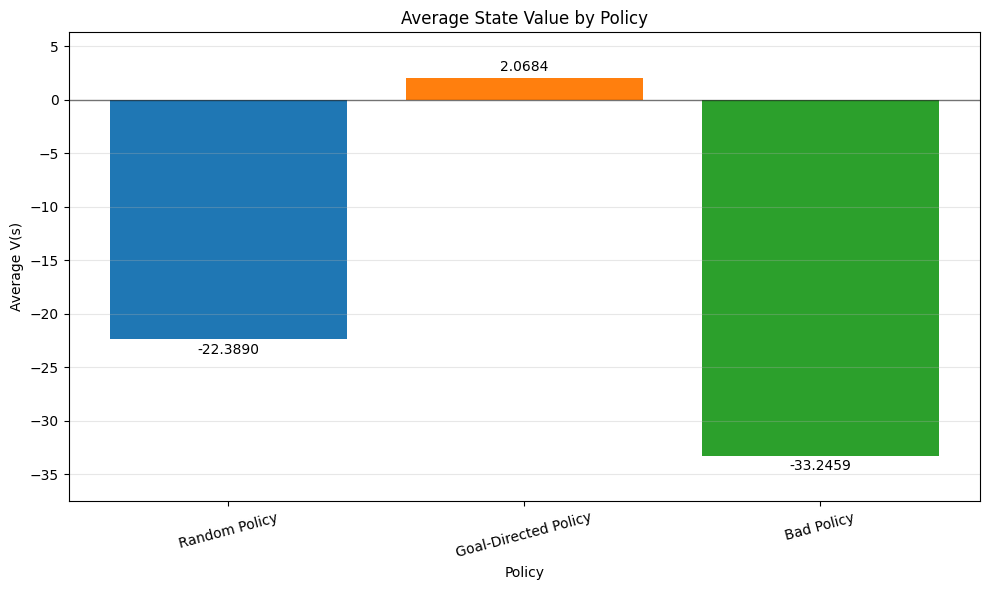

Saved 4 plots to d:\Machine_Learning_projects\RL_Projects\reinforcement-learning-series\results\week_05/


In [12]:
results_dir = project_root / "results" / "week_05"
results_dir.mkdir(parents=True, exist_ok=True)

plot_value_function_grid(
    random_grid, env,
    title="State-Value Function - Random Policy (gamma=0.9)",
    save_path=results_dir / "random_policy_value_function.png",
)

plot_value_function_grid(
    goal_grid, env,
    title="State-Value Function - Goal-Directed Policy (gamma=0.9)",
    save_path=results_dir / "goal_directed_policy_value_function.png",
)

plot_value_convergence(
    convergence_histories,
    save_path=results_dir / "value_convergence.png",
)

plot_policy_value_comparison(
    avg_values,
    save_path=results_dir / "policy_value_comparison.png",
)

print(f"Saved 4 plots to {results_dir}/")

## Final Interpretation

After running iterative policy evaluation on all three policies:

**Goal-Directed Policy** has the highest state values overall. Because it reaches the goal efficiently with few steps and rarely hits obstacles, states along the best path to the goal carry high positive values. States adjacent to the goal can already recover much of the goal reward through one or two steps.

**Random Policy** has much lower state values. Random actions frequently result in invalid moves (reward -5) and take many more steps to reach the goal (reward -1 per step). This pushes most state values deep into negative territory.

**Bad Policy** has the lowest state values. By systematically preferring up and left - away from the goal at (4, 4) - the agent accumulates penalties with little chance of eventually reaching the goal.

**Important:** policy evaluation does not change the policy. Its only purpose is to compute v<sub>pi</sub>(s) accurately for the given fixed policy. This is the foundation for the next step: using v<sub>pi</sub>(s) to identify improvements — which is **policy improvement**, the topic of Week 6.

## Technical Takeaways

- **v<sub>pi</sub>(s)** is the expected return starting from state s and following policy pi.
- **q<sub>pi</sub>(s, a)** is the expected return after taking action a in state s and then following pi.
- The **Bellman expectation equation** expresses v<sub>pi</sub>(s) recursively: current state value = policy-weighted average of (immediate reward + discounted next-state value).
- **Iterative policy evaluation** repeatedly applies Bellman backups across all states until the value estimates converge (delta < theta).
- Convergence is measured by the maximum change in any state's value across a full sweep.
- **Terminal state values remain 0** throughout - there is no future return after reaching the goal.
- **Obstacle states are not evaluated** - they are excluded from the evaluation state set, and attempted moves into them keep the agent in place with the invalid-move penalty.
- The value function completely characterises the long-term behaviour of a fixed policy.